# NCES CCD Fiscal Data Analysis

## Purpose

The NCES Common Core of Data fiscal dataset provides district-level information about public school system finances and resource allocation.

For this project, the fiscal data are used to examine variation in school-system financial resources across districts and states, including revenue, expenditures, and per-pupil spending measures where available.

This dataset does not measure individual mental health outcomes. Its role is to provide school-system resource context that can later be compared with community vulnerability and other structural indicators.

In [1]:
import pandas as pd
from pathlib import Path

data_path = Path("../../data/cleaned/NCES_CCD_2022_23_Fiscal_cleaned.csv")

nces_fiscal = pd.read_csv(data_path)

print("Loaded:", data_path.name)
print("Dataset shape:", nces_fiscal.shape)

nces_fiscal.head()

Loaded: NCES_CCD_2022_23_Fiscal_cleaned.csv
Dataset shape: (17788, 36)


,LEAID,NAME,STNAME,STABBR,FIPST,CONUM,YEAR,LEA_RESOURCE_TYPE,CHARTER_STATUS,PER_PUPIL_COMPARABLE,...,EXP_PER_PUPIL,INST_PER_PUPIL,SUPPORT_PER_PUPIL,FEDREV_PER_PUPIL,STATEREV_PER_PUPIL,LOCALREV_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL,SCHOOL_ADMIN_PER_PUPIL,TRANSPORT_PER_PUPIL
0,100005,Albertville City,Alabama,AL,1,1095,23,Regular School District,No charter,True,...,13794.237288,6276.610169,3791.864407,3575.593220,8060.169492,3776.101695,900.677966,412.203390,554.576271,495.762712
1,100006,Marshall County,Alabama,AL,1,1095,23,Regular School District,No charter,True,...,14746.261133,7065.367165,5097.798689,3019.324483,8222.315577,3499.075786,910.603260,447.823895,785.246177,799.193413
2,100007,Hoover City,Alabama,AL,1,1073,23,Regular School District,No charter,True,...,15545.474663,8515.674559,4971.158811,830.862285,6845.983625,9265.250424,1037.028841,567.603452,880.135723,647.414620
3,100008,Madison City,Alabama,AL,1,1089,23,Regular School District,No charter,True,...,15138.699591,6829.551832,4278.441433,903.230979,8181.111200,7519.121302,995.430129,856.570192,584.221919,459.793153
4,100011,Leeds City,Alabama,AL,1,1073,23,Regular School District,No charter,True,...,12842.105263,6883.040936,4421.502474,1654.071075,8216.824112,5327.035538,906.882591,487.629330,663.517769,508.771930


In [2]:
print("Columns:")
for col in nces_fiscal.columns:
    print(col)

Columns:
LEAID
NAME
STNAME
STABBR
FIPST
CONUM
YEAR
LEA_RESOURCE_TYPE
CHARTER_STATUS
PER_PUPIL_COMPARABLE
MEMBERSCH
TOTALREV
TFEDREV
TSTREV
TLOCREV
TOTALEXP
TCURELSC
TCURINST
TCURSSVC
TCUROTH
TCAPOUT
E17
E07
E09
V45
REV_PER_PUPIL
EXP_PER_PUPIL
INST_PER_PUPIL
SUPPORT_PER_PUPIL
FEDREV_PER_PUPIL
STATEREV_PER_PUPIL
LOCALREV_PER_PUPIL
STUDENT_SUPPORT_PER_PUPIL
INST_STAFF_SUPPORT_PER_PUPIL
SCHOOL_ADMIN_PER_PUPIL
TRANSPORT_PER_PUPIL


## Key Fiscal Measures

The cleaned NCES fiscal dataset contains both total district revenue/expenditure measures and standardized per-pupil measures.

Because districts vary substantially in enrollment size, the primary analysis will focus on **per-pupil measures**, which allow more meaningful comparisons across districts.

Key measures include:

- total revenue per pupil
- total expenditure per pupil
- instructional spending per pupil
- support services spending per pupil
- student support spending per pupil
- instructional staff support per pupil
- school administration spending per pupil
- transportation spending per pupil
- federal, state, and local revenue per pupil

District enrollment and total financial measures are retained for context.

In [3]:
fiscal_measures = [
    "LEAID",
    "NAME",
    "STNAME",
    "STABBR",
    "MEMBERSCH",
    "LEA_RESOURCE_TYPE",
    "CHARTER_STATUS",
    "PER_PUPIL_COMPARABLE",
    "REV_PER_PUPIL",
    "EXP_PER_PUPIL",
    "INST_PER_PUPIL",
    "SUPPORT_PER_PUPIL",
    "STUDENT_SUPPORT_PER_PUPIL",
    "INST_STAFF_SUPPORT_PER_PUPIL",
    "SCHOOL_ADMIN_PER_PUPIL",
    "TRANSPORT_PER_PUPIL",
    "FEDREV_PER_PUPIL",
    "STATEREV_PER_PUPIL",
    "LOCALREV_PER_PUPIL"
]

fiscal_focus = nces_fiscal[fiscal_measures].copy()

print("Focused fiscal dataset shape:", fiscal_focus.shape)

fiscal_focus.head()

Focused fiscal dataset shape: (17788, 19)


,LEAID,NAME,STNAME,STABBR,MEMBERSCH,LEA_RESOURCE_TYPE,CHARTER_STATUS,PER_PUPIL_COMPARABLE,REV_PER_PUPIL,EXP_PER_PUPIL,INST_PER_PUPIL,SUPPORT_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL,SCHOOL_ADMIN_PER_PUPIL,TRANSPORT_PER_PUPIL,FEDREV_PER_PUPIL,STATEREV_PER_PUPIL,LOCALREV_PER_PUPIL
0,100005,Albertville City,Alabama,AL,5900,Regular School District,No charter,True,15411.864407,13794.237288,6276.610169,3791.864407,900.677966,412.203390,554.576271,495.762712,3575.593220,8060.169492,3776.101695
1,100006,Marshall County,Alabama,AL,5951,Regular School District,No charter,True,14740.715846,14746.261133,7065.367165,5097.798689,910.603260,447.823895,785.246177,799.193413,3019.324483,8222.315577,3499.075786
2,100007,Hoover City,Alabama,AL,13557,Regular School District,No charter,True,16942.096334,15545.474663,8515.674559,4971.158811,1037.028841,567.603452,880.135723,647.414620,830.862285,6845.983625,9265.250424
3,100008,Madison City,Alabama,AL,12473,Regular School District,No charter,True,16603.463481,15138.699591,6829.551832,4278.441433,995.430129,856.570192,584.221919,459.793153,903.230979,8181.111200,7519.121302
4,100011,Leeds City,Alabama,AL,2223,Regular School District,No charter,True,15197.930724,12842.105263,6883.040936,4421.502474,906.882591,487.629330,663.517769,508.771930,1654.071075,8216.824112,5327.035538


In [4]:
# Check comparability and missingness before analysis

print("Per-pupil comparable:")
print(fiscal_focus["PER_PUPIL_COMPARABLE"].value_counts(dropna=False))

print("\nMissing values:")
display(
    fiscal_focus.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing")
)

Per-pupil comparable:
PER_PUPIL_COMPARABLE
True     17366
False      422
Name: count, dtype: int64

Missing values:


,Missing
EXP_PER_PUPIL,380
INST_PER_PUPIL,380
STATEREV_PER_PUPIL,380
FEDREV_PER_PUPIL,380
TRANSPORT_PER_PUPIL,380
SCHOOL_ADMIN_PER_PUPIL,380
INST_STAFF_SUPPORT_PER_PUPIL,380
STUDENT_SUPPORT_PER_PUPIL,380
SUPPORT_PER_PUPIL,380
LOCALREV_PER_PUPIL,380


## Analysis Sample

The cleaned fiscal dataset contains 17,788 school districts.

NCES identifies 17,366 districts as appropriate for per-pupil comparisons, while 422 are marked as non-comparable. Because the primary analysis compares financial resources across districts of different sizes, the fiscal analysis is restricted to districts marked as comparable.

Missingness among the selected per-pupil measures is limited, with 380 missing observations across the primary fiscal indicators.

The resulting analysis therefore focuses on comparable districts with valid per-pupil financial data.

In [5]:
# Restrict analysis to districts appropriate for per-pupil comparison

fiscal_analysis = fiscal_focus[
    fiscal_focus["PER_PUPIL_COMPARABLE"] == True
].copy()

print("Comparable districts:", len(fiscal_analysis))

print("\nMissing per-pupil values after comparability filter:")

per_pupil_cols = [
    "REV_PER_PUPIL",
    "EXP_PER_PUPIL",
    "INST_PER_PUPIL",
    "SUPPORT_PER_PUPIL",
    "STUDENT_SUPPORT_PER_PUPIL",
    "INST_STAFF_SUPPORT_PER_PUPIL",
    "SCHOOL_ADMIN_PER_PUPIL",
    "TRANSPORT_PER_PUPIL",
    "FEDREV_PER_PUPIL",
    "STATEREV_PER_PUPIL",
    "LOCALREV_PER_PUPIL"
]

display(
    fiscal_analysis[per_pupil_cols]
    .isna()
    .sum()
    .to_frame("Missing")
)

Comparable districts: 17366

Missing per-pupil values after comparability filter:


,Missing
REV_PER_PUPIL,336
EXP_PER_PUPIL,336
INST_PER_PUPIL,336
SUPPORT_PER_PUPIL,336
STUDENT_SUPPORT_PER_PUPIL,336
INST_STAFF_SUPPORT_PER_PUPIL,336
SCHOOL_ADMIN_PER_PUPIL,336
TRANSPORT_PER_PUPIL,336
FEDREV_PER_PUPIL,336
STATEREV_PER_PUPIL,336


In [6]:
fiscal_summary = (
    fiscal_analysis[per_pupil_cols]
    .describe()
    .T[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
    ]
    .round(1)
)

fiscal_summary

,count,mean,std,min,25%,50%,75%,max
REV_PER_PUPIL,17030.0,21688.9,46714.8,0.0,15260.0,18678.9,24191.2,5666000.0
EXP_PER_PUPIL,17030.0,21681.3,41741.1,0.0,14836.5,18268.0,24059.4,4925000.0
INST_PER_PUPIL,17030.0,10266.3,15482.3,0.0,7327.0,8911.9,11442.0,1722000.0
SUPPORT_PER_PUPIL,17030.0,7170.5,11552.1,0.0,4681.6,5985.8,8108.4,1201000.0
STUDENT_SUPPORT_PER_PUPIL,17030.0,999.8,1224.0,0.0,473.2,764.0,1217.8,67428.6
INST_STAFF_SUPPORT_PER_PUPIL,17030.0,860.7,1722.3,0.0,288.3,557.3,911.1,68000.0
SCHOOL_ADMIN_PER_PUPIL,17030.0,1082.2,3435.1,0.0,643.2,855.4,1177.0,432000.0
TRANSPORT_PER_PUPIL,17030.0,725.8,825.2,0.0,289.3,578.5,945.2,35000.0
FEDREV_PER_PUPIL,17030.0,2764.6,6038.9,0.0,1256.7,2100.5,3297.5,558000.0
STATEREV_PER_PUPIL,17030.0,9895.5,13535.1,0.0,6343.5,8868.1,11692.4,1003000.0


## Distribution of Per-Pupil Spending

Per-pupil fiscal measures are strongly right-skewed.

For example, the median total revenue per pupil is approximately $18,679 and the median total expenditure per pupil is approximately $18,268, while maximum values are several orders of magnitude higher.

Because extreme values can substantially influence means and visual scales, the analysis emphasizes medians, interquartile ranges, and trimmed visualizations when comparing districts and states.

In [7]:
state_fiscal_summary = (
    fiscal_analysis
    .groupby(["STNAME", "STABBR"])
    [per_pupil_cols]
    .median()
    .reset_index()
)

state_fiscal_summary[
    [
        "STNAME",
        "REV_PER_PUPIL",
        "EXP_PER_PUPIL",
        "INST_PER_PUPIL",
        "STUDENT_SUPPORT_PER_PUPIL",
        "INST_STAFF_SUPPORT_PER_PUPIL"
    ]
].sort_values(
    "EXP_PER_PUPIL",
    ascending=False
).head(15)

,STNAME,REV_PER_PUPIL,EXP_PER_PUPIL,INST_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL
1,Alaska,34065.930143,36908.630952,15637.689579,1188.276064,3074.341431
8,District of Columbia,36427.933772,33263.646646,13983.449988,3139.267197,611.750384
32,New York,30420.600358,30973.712116,16296.245385,997.342233,1617.291656
30,New Jersey,29782.407407,29535.211268,15388.438208,3017.374517,859.946133
29,New Hampshire,28679.245283,28425.211665,13878.326996,1993.506494,754.098361
6,Connecticut,28698.374953,28252.835794,14251.230789,1981.361840,686.612112
45,Vermont,26966.685345,27960.606537,12241.596048,1521.671902,789.477114
21,Massachusetts,23504.347826,25092.457421,13212.543554,2073.184098,856.992639
39,Rhode Island,23624.847592,23760.470478,11492.810329,2399.318139,863.118454
50,Wyoming,22803.258126,22928.371362,11820.164089,1337.118361,993.122604


## State-Level Fiscal Variation

Median per-pupil spending varies substantially across states.

Because fiscal distributions contain extreme district-level outliers, state comparisons are based on the median district value rather than the mean.

The formal state-level analysis is restricted to the 50 U.S. states.

In [8]:
# Restrict formal state-level fiscal analysis to the 50 U.S. states

state_fiscal_50 = state_fiscal_summary[
    state_fiscal_summary["STNAME"] != "District of Columbia"
].copy()

state_fiscal_50[
    [
        "STNAME",
        "REV_PER_PUPIL",
        "EXP_PER_PUPIL",
        "INST_PER_PUPIL",
        "STUDENT_SUPPORT_PER_PUPIL",
        "INST_STAFF_SUPPORT_PER_PUPIL"
    ]
].sort_values(
    "EXP_PER_PUPIL",
    ascending=False
).head(15)

,STNAME,REV_PER_PUPIL,EXP_PER_PUPIL,INST_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL
1,Alaska,34065.930143,36908.630952,15637.689579,1188.276064,3074.341431
32,New York,30420.600358,30973.712116,16296.245385,997.342233,1617.291656
30,New Jersey,29782.407407,29535.211268,15388.438208,3017.374517,859.946133
29,New Hampshire,28679.245283,28425.211665,13878.326996,1993.506494,754.098361
6,Connecticut,28698.374953,28252.835794,14251.230789,1981.361840,686.612112
45,Vermont,26966.685345,27960.606537,12241.596048,1521.671902,789.477114
21,Massachusetts,23504.347826,25092.457421,13212.543554,2073.184098,856.992639
39,Rhode Island,23624.847592,23760.470478,11492.810329,2399.318139,863.118454
50,Wyoming,22803.258126,22928.371362,11820.164089,1337.118361,993.122604
19,Maine,22620.071685,22730.964467,11088.709677,1381.663113,816.326531


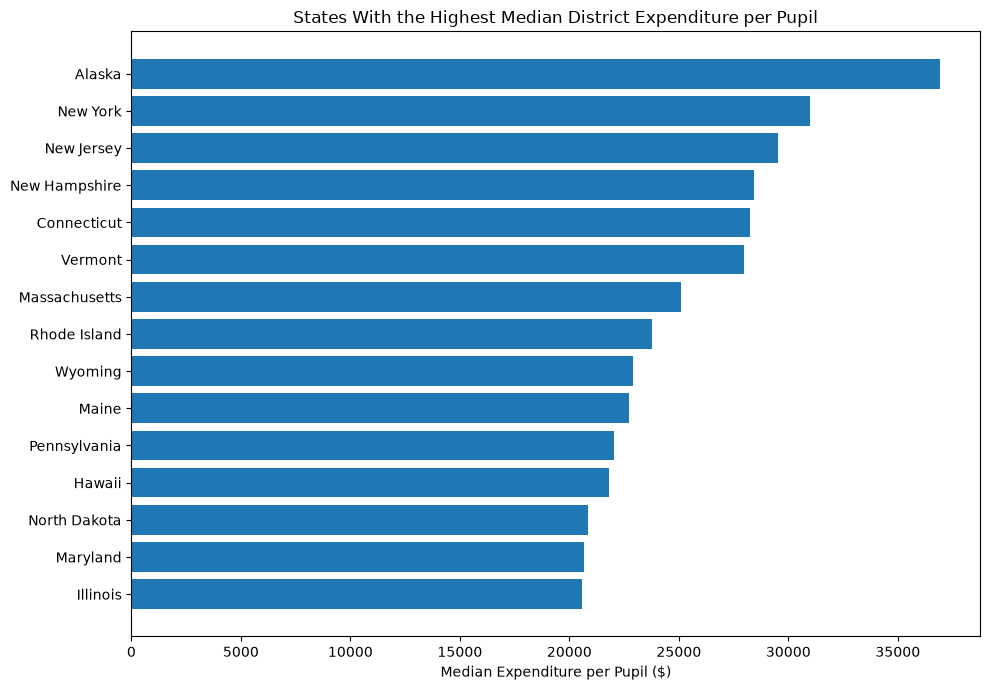

In [9]:
import matplotlib.pyplot as plt

top_spending_states = (
    state_fiscal_50
    .sort_values("EXP_PER_PUPIL", ascending=False)
    .head(15)
    .sort_values("EXP_PER_PUPIL")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_spending_states["STNAME"],
    top_spending_states["EXP_PER_PUPIL"]
)

plt.xlabel("Median Expenditure per Pupil ($)")
plt.ylabel("")
plt.title("States With the Highest Median District Expenditure per Pupil")

plt.tight_layout()
plt.show()

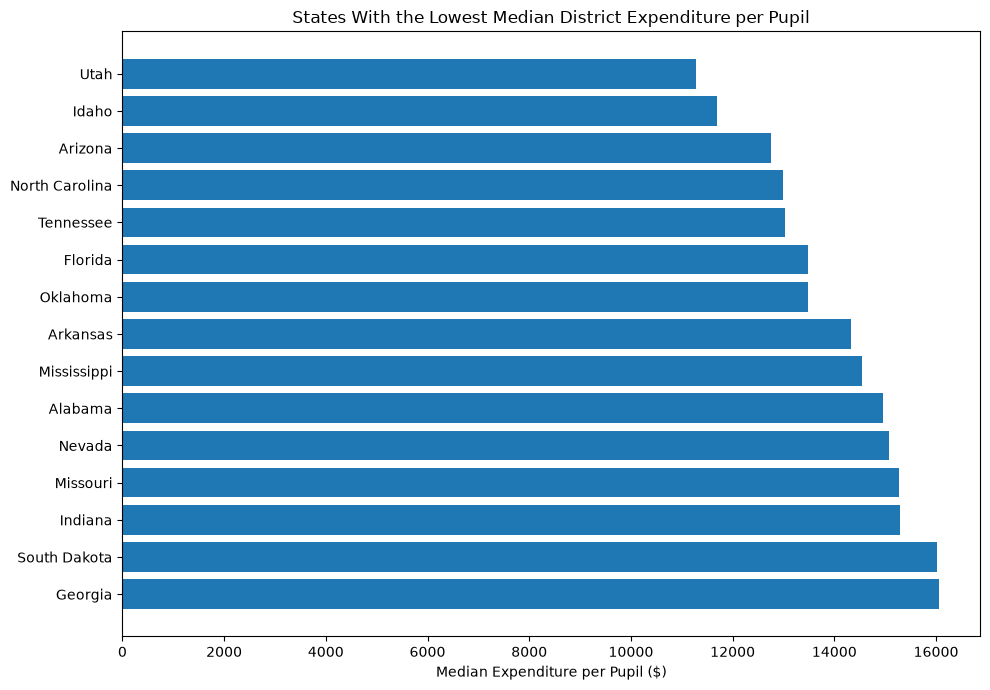

In [10]:
bottom_spending_states = (
    state_fiscal_50
    .sort_values("EXP_PER_PUPIL", ascending=True)
    .head(15)
    .sort_values("EXP_PER_PUPIL", ascending=False)
)

plt.figure(figsize=(10, 7))

plt.barh(
    bottom_spending_states["STNAME"],
    bottom_spending_states["EXP_PER_PUPIL"]
)

plt.xlabel("Median Expenditure per Pupil ($)")
plt.ylabel("")
plt.title("States With the Lowest Median District Expenditure per Pupil")

plt.tight_layout()
plt.show()

In [11]:
state_fiscal_50[
    [
        "STNAME",
        "REV_PER_PUPIL",
        "EXP_PER_PUPIL",
        "INST_PER_PUPIL",
        "STUDENT_SUPPORT_PER_PUPIL",
        "INST_STAFF_SUPPORT_PER_PUPIL"
    ]
].sort_values(
    "EXP_PER_PUPIL",
    ascending=True
).head(15)

,STNAME,REV_PER_PUPIL,EXP_PER_PUPIL,INST_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL
44,Utah,11870.167526,11284.083344,6092.024898,586.547297,292.710310
12,Idaho,12487.902247,11698.269596,6411.747163,381.675573,353.339644
2,Arizona,13610.775862,12750.000000,5915.104741,827.510917,392.638037
33,North Carolina,12532.408093,12986.886815,7112.047799,541.692357,282.776699
42,Tennessee,13333.027735,13021.023791,6790.749018,606.102725,701.948495
9,Florida,13761.518726,13474.028808,6522.172007,580.759494,734.271523
36,Oklahoma,13936.966572,13477.209781,6457.151352,782.402988,306.652900
3,Arkansas,14173.356106,14320.396367,6824.561404,637.733377,783.427495
24,Mississippi,15229.942515,14551.414405,7039.679497,690.010274,552.730483
0,Alabama,15651.234568,14948.833710,7256.583898,953.938277,468.590336


In [12]:
state_fiscal_50[
    [
        "STNAME",
        "REV_PER_PUPIL",
        "EXP_PER_PUPIL",
        "INST_PER_PUPIL",
        "STUDENT_SUPPORT_PER_PUPIL",
        "INST_STAFF_SUPPORT_PER_PUPIL"
    ]
].query("STNAME == 'Louisiana'")

,STNAME,REV_PER_PUPIL,EXP_PER_PUPIL,INST_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL
18,Louisiana,16939.869281,16332.853026,7884.053156,856.070667,738.188976


In [14]:
state_spending_rank = (
    state_fiscal_50[
        [
            "STNAME",
            "EXP_PER_PUPIL",
            "STUDENT_SUPPORT_PER_PUPIL"
        ]
    ]
    .sort_values("EXP_PER_PUPIL")
    .reset_index(drop=True)
)

state_spending_rank["Expenditure_Rank_Low_to_High"] = (
    state_spending_rank.index + 1
)

state_spending_rank.query("STNAME == 'Louisiana'")

,STNAME,EXP_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,Expenditure_Rank_Low_to_High
20,Louisiana,16332.853026,856.070667,21


## Student Support Spending

Total school spending provides broad resource context, but student support spending is more directly relevant to the pediatric mental health access question.

Student support expenditures can include services that support students' educational, social, emotional, and health-related needs.

To compare states fairly, the analysis uses the median district-level student support spending per pupil.

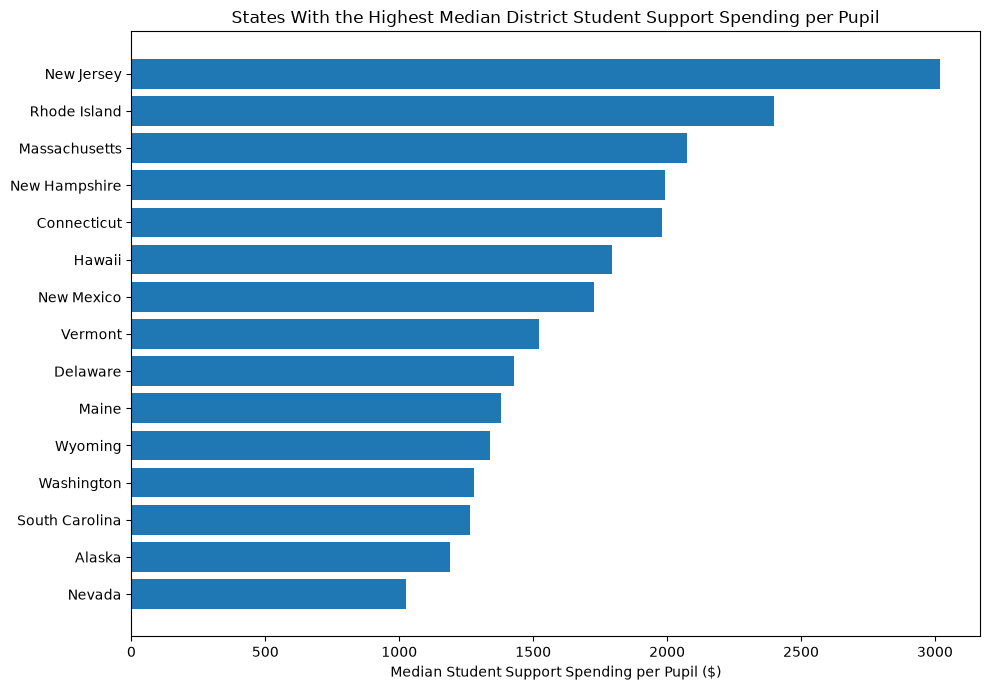

In [15]:
top_student_support_states = (
    state_fiscal_50
    .sort_values("STUDENT_SUPPORT_PER_PUPIL", ascending=False)
    .head(15)
    .sort_values("STUDENT_SUPPORT_PER_PUPIL")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_student_support_states["STNAME"],
    top_student_support_states["STUDENT_SUPPORT_PER_PUPIL"]
)

plt.xlabel("Median Student Support Spending per Pupil ($)")
plt.ylabel("")
plt.title(
    "States With the Highest Median District Student Support Spending per Pupil"
)

plt.tight_layout()
plt.show()

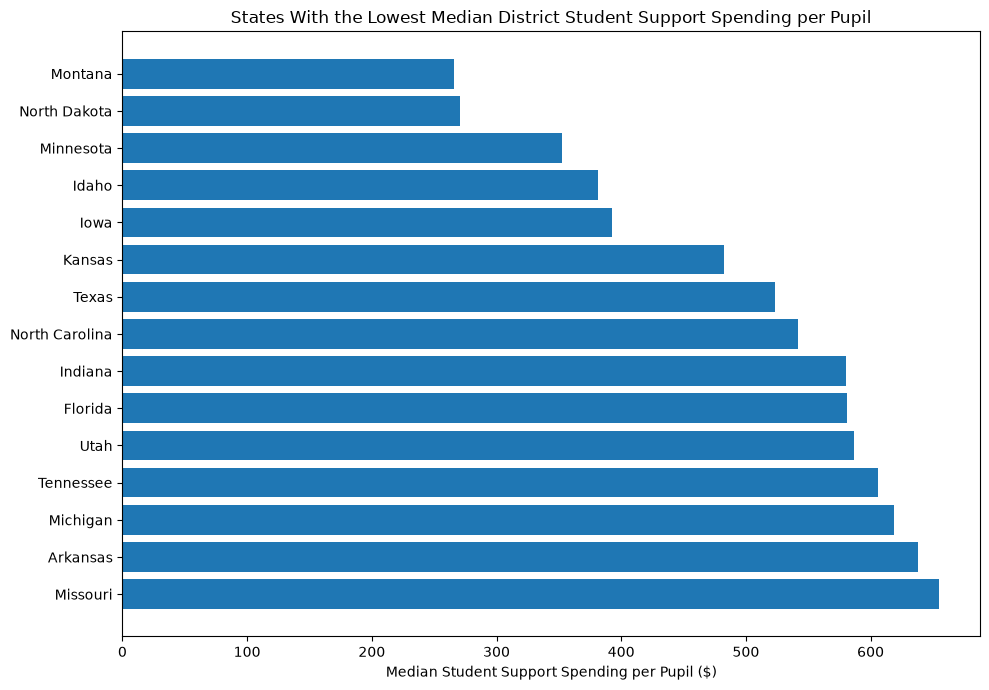

In [16]:
bottom_student_support_states = (
    state_fiscal_50
    .sort_values("STUDENT_SUPPORT_PER_PUPIL", ascending=True)
    .head(15)
    .sort_values("STUDENT_SUPPORT_PER_PUPIL", ascending=False)
)

plt.figure(figsize=(10, 7))

plt.barh(
    bottom_student_support_states["STNAME"],
    bottom_student_support_states["STUDENT_SUPPORT_PER_PUPIL"]
)

plt.xlabel("Median Student Support Spending per Pupil ($)")
plt.ylabel("")
plt.title(
    "States With the Lowest Median District Student Support Spending per Pupil"
)

plt.tight_layout()
plt.show()

## Overall Spending vs. Student Support Spending

A district or state may spend relatively more overall without allocating the same proportion of resources to student support.

Comparing total expenditure per pupil with student support expenditure per pupil helps distinguish broad school-system spending from resources more directly connected to student-facing support services.

In [17]:
state_support_comparison = (
    state_fiscal_50[
        [
            "STNAME",
            "EXP_PER_PUPIL",
            "STUDENT_SUPPORT_PER_PUPIL"
        ]
    ]
    .copy()
)

state_support_comparison["STUDENT_SUPPORT_SHARE_PCT"] = (
    state_support_comparison["STUDENT_SUPPORT_PER_PUPIL"]
    / state_support_comparison["EXP_PER_PUPIL"]
    * 100
)

state_support_comparison[
    [
        "STNAME",
        "EXP_PER_PUPIL",
        "STUDENT_SUPPORT_PER_PUPIL",
        "STUDENT_SUPPORT_SHARE_PCT"
    ]
].sort_values(
    "STUDENT_SUPPORT_SHARE_PCT",
    ascending=False
).head(15).round(1)

,STNAME,EXP_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,STUDENT_SUPPORT_SHARE_PCT
30,New Jersey,29535.2,3017.4,10.2
39,Rhode Island,23760.5,2399.3,10.1
31,New Mexico,20184.3,1727.3,8.6
21,Massachusetts,25092.5,2073.2,8.3
11,Hawaii,21803.9,1795.2,8.2
7,Delaware,17883.0,1428.1,8.0
40,South Carolina,16478.1,1262.3,7.7
29,New Hampshire,28425.2,1993.5,7.0
6,Connecticut,28252.8,1981.4,7.0
28,Nevada,15074.3,1025.1,6.8


## Relationships Among Fiscal Measures

Correlation analysis is used to examine how different forms of district spending relate to one another.

This helps determine whether districts with higher overall expenditures also consistently spend more on instruction, student support, staff support, administration, and transportation.

In [18]:
fiscal_corr_vars = [
    "EXP_PER_PUPIL",
    "INST_PER_PUPIL",
    "SUPPORT_PER_PUPIL",
    "STUDENT_SUPPORT_PER_PUPIL",
    "INST_STAFF_SUPPORT_PER_PUPIL",
    "SCHOOL_ADMIN_PER_PUPIL",
    "TRANSPORT_PER_PUPIL"
]

fiscal_correlations = (
    fiscal_analysis[fiscal_corr_vars]
    .corr()
    .round(2)
)

fiscal_correlations

,EXP_PER_PUPIL,INST_PER_PUPIL,SUPPORT_PER_PUPIL,STUDENT_SUPPORT_PER_PUPIL,INST_STAFF_SUPPORT_PER_PUPIL,SCHOOL_ADMIN_PER_PUPIL,TRANSPORT_PER_PUPIL
EXP_PER_PUPIL,1.00,0.96,0.94,0.42,0.15,0.27,0.14
INST_PER_PUPIL,0.96,1.00,0.95,0.44,0.17,0.38,0.14
SUPPORT_PER_PUPIL,0.94,0.95,1.00,0.51,0.30,0.45,0.21
STUDENT_SUPPORT_PER_PUPIL,0.42,0.44,0.51,1.00,0.13,0.30,0.21
INST_STAFF_SUPPORT_PER_PUPIL,0.15,0.17,0.30,0.13,1.00,0.28,0.01
SCHOOL_ADMIN_PER_PUPIL,0.27,0.38,0.45,0.30,0.28,1.00,0.04
TRANSPORT_PER_PUPIL,0.14,0.14,0.21,0.21,0.01,0.04,1.00


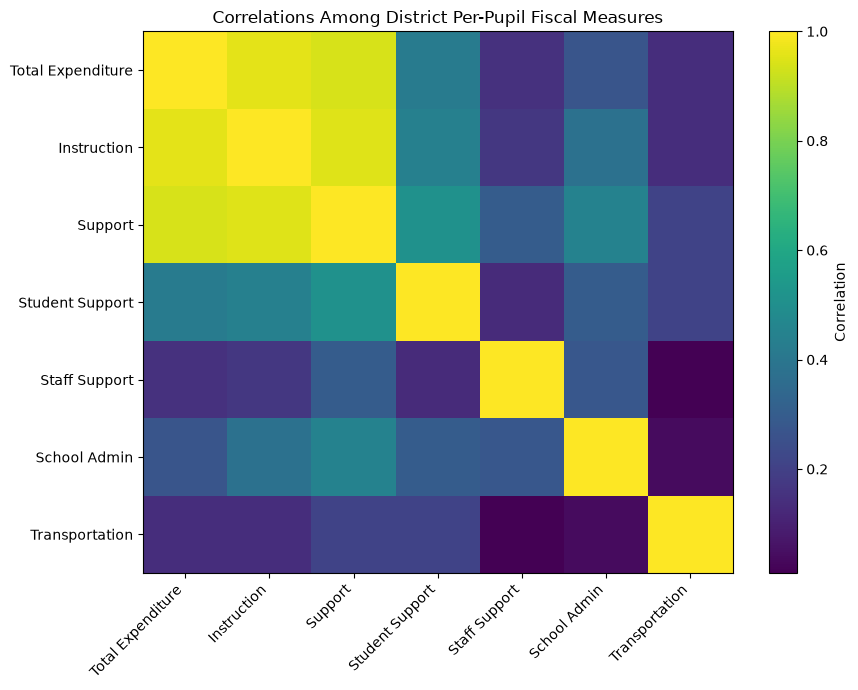

In [19]:
plt.figure(figsize=(9, 7))

plt.imshow(
    fiscal_correlations,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(fiscal_corr_vars)),
    [
        "Total Expenditure",
        "Instruction",
        "Support",
        "Student Support",
        "Staff Support",
        "School Admin",
        "Transportation"
    ],
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(fiscal_corr_vars)),
    [
        "Total Expenditure",
        "Instruction",
        "Support",
        "Student Support",
        "Staff Support",
        "School Admin",
        "Transportation"
    ]
)

plt.title("Correlations Among District Per-Pupil Fiscal Measures")

plt.tight_layout()
plt.show()

## Fiscal Analysis Findings

School-system financial resources vary substantially across states, both in overall spending and in the amount devoted specifically to student support.

### Overall Expenditure

Median district expenditure per pupil ranged widely across states. Alaska, New York, and New Jersey were among the states with the highest median district expenditures, while Utah, Idaho, Arizona, North Carolina, and Tennessee were among the lowest.

Louisiana, which had the highest concentration of multi-factor community vulnerability in the ACS analysis, ranked 21st from lowest to highest in median district expenditure per pupil. This indicates that high community vulnerability does not necessarily correspond directly with the lowest overall school spending.

### Student Support Spending

Student-support spending showed a different geographic pattern from total expenditure.

New Jersey had the highest median district student-support spending at approximately $3,017 per pupil, followed by Rhode Island at approximately $2,399. Massachusetts, New Hampshire, Connecticut, Hawaii, and New Mexico also ranked relatively high.

At the lower end, Montana and North Dakota had median student-support spending below $300 per pupil. Texas, North Carolina, Florida, Utah, Tennessee, and several Midwestern states also appeared among the lower-spending states.

New Mexico is particularly notable because it combines high community vulnerability with relatively high student-support spending. Approximately 8.6% of its median district expenditure was devoted to student support, the third-highest share among the 50 states.

### Relationship Between Overall and Student-Support Spending

Correlation analysis showed that total expenditure per pupil was very strongly associated with instructional spending (`r = 0.96`) and overall support spending (`r = 0.94`).

However, total expenditure had only a moderate relationship with student-support spending (`r = 0.42`).

This suggests that higher overall school spending does not necessarily translate into proportionally greater spending on student-facing support services. Resource allocation patterns therefore provide information that total expenditure alone cannot capture.

In [20]:
priority_states = [
    "Louisiana",
    "New Mexico",
    "Mississippi",
    "Georgia",
    "Alaska",
    "Alabama",
    "South Carolina",
    "North Carolina",
    "Texas",
    "West Virginia"
]

priority_fiscal = (
    state_support_comparison[
        state_support_comparison["STNAME"].isin(priority_states)
    ]
    .copy()
)

# Add spending ranks among all 50 states
priority_fiscal["Overall_Spending_Rank_Low_to_High"] = (
    priority_fiscal["STNAME"]
    .map(
        state_fiscal_50
        .set_index("STNAME")["EXP_PER_PUPIL"]
        .rank(method="min", ascending=True)
    )
)

priority_fiscal["Student_Support_Rank_Low_to_High"] = (
    priority_fiscal["STNAME"]
    .map(
        state_fiscal_50
        .set_index("STNAME")["STUDENT_SUPPORT_PER_PUPIL"]
        .rank(method="min", ascending=True)
    )
)

priority_fiscal[
    [
        "STNAME",
        "EXP_PER_PUPIL",
        "Overall_Spending_Rank_Low_to_High",
        "STUDENT_SUPPORT_PER_PUPIL",
        "Student_Support_Rank_Low_to_High",
        "STUDENT_SUPPORT_SHARE_PCT"
    ]
].sort_values(
    "STUDENT_SUPPORT_PER_PUPIL"
).round(1)

,STNAME,EXP_PER_PUPIL,Overall_Spending_Rank_Low_to_High,STUDENT_SUPPORT_PER_PUPIL,Student_Support_Rank_Low_to_High,STUDENT_SUPPORT_SHARE_PCT
43,Texas,16092.9,16.0,523.7,7.0,3.3
33,North Carolina,12986.9,4.0,541.7,8.0,4.2
24,Mississippi,14551.4,9.0,690.0,19.0,4.7
10,Georgia,16061.3,15.0,855.8,26.0,5.3
18,Louisiana,16332.9,21.0,856.1,27.0,5.2
0,Alabama,14948.8,10.0,953.9,31.0,6.4
48,West Virginia,16219.7,19.0,970.7,33.0,6.0
1,Alaska,36908.6,50.0,1188.3,37.0,3.2
40,South Carolina,16478.1,22.0,1262.3,38.0,7.7
31,New Mexico,20184.3,33.0,1727.3,44.0,8.6


## NCES Fiscal Analysis Summary

The NCES fiscal analysis shows substantial variation in both overall school spending and the allocation of resources to student support across the 50 states.

### Overall School Spending

Median district expenditure per pupil varied widely across states. Alaska had the highest median district expenditure, while Utah, Idaho, Arizona, North Carolina, and Tennessee were among the lowest.

Several states identified as highly vulnerable in the ACS analysis also appeared toward the lower end of the spending distribution. North Carolina ranked fourth-lowest, Mississippi ninth-lowest, Alabama tenth-lowest, Georgia fifteenth-lowest, and Texas sixteenth-lowest in median district expenditure per pupil.

However, the relationship was not consistent across all high-vulnerability states. Louisiana ranked 21st from lowest to highest, New Mexico ranked 33rd, and Alaska had the highest median district expenditure of all 50 states.

### Student Support Spending

Student-support spending showed a different geographic pattern from total school expenditure.

Among states previously identified as having high concentrations of community vulnerability, Texas and North Carolina stood out for relatively low student-support spending, ranking seventh- and eighth-lowest respectively.

By contrast, New Mexico ranked 44th from lowest to highest, placing it among the states with the highest median student-support spending. Approximately 8.6% of its median district expenditures were devoted to student support.

Louisiana fell closer to the middle of the distribution, ranking 27th in student-support spending.

### Statistical Relationships

Total expenditure per pupil was strongly correlated with instructional spending (`r = 0.96`) and overall support spending (`r = 0.94`).

The relationship between total expenditure and student-support spending was substantially weaker (`r = 0.42`).

This indicates that districts with higher overall expenditures do not necessarily allocate proportionally more resources to student-facing support services.

### Interpretation

The fiscal findings do not support a simple relationship in which greater community vulnerability corresponds directly with lower school spending.

Instead, highly vulnerable states show different resource profiles. Some combine high community vulnerability with relatively low overall and student-support spending, while others maintain comparatively high levels of school or student-support expenditure.

These findings suggest that both the **amount of funding available** and **how that funding is allocated** are important when evaluating the school-system context surrounding pediatric mental health access.

In [23]:
import nbformat as nbf
from pathlib import Path

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

fiscal_path = Path("03_nces_fiscal_data_analysis.ipynb")

master_path = Path(
    "../Final_Data_Analysis/07_full_project_analysis.ipynb"
)

# ---------------------------------------------------------
# Read both notebooks
# ---------------------------------------------------------

fiscal_nb = nbf.read(fiscal_path, as_version=4)
master_nb = nbf.read(master_path, as_version=4)

# ---------------------------------------------------------
# Find NCES Fiscal section in master notebook
# ---------------------------------------------------------

fiscal_start = None
fiscal_end = None

for i, cell in enumerate(master_nb.cells):

    if (
        cell.cell_type == "markdown"
        and "# 4. NCES Fiscal" in cell.source
    ):
        fiscal_start = i

    if (
        fiscal_start is not None
        and cell.cell_type == "markdown"
        and "# 5. NCES Nonfiscal" in cell.source
    ):
        fiscal_end = i
        break

if fiscal_start is None:
    raise ValueError("Could not find the NCES Fiscal section in the master notebook.")

if fiscal_end is None:
    raise ValueError("Could not find the NCES Nonfiscal section in the master notebook.")

# ---------------------------------------------------------
# Copy finished fiscal notebook cells
#
# Skip its standalone title because the master already
# contains the NCES Fiscal section heading.
# ---------------------------------------------------------

fiscal_cells = fiscal_nb.cells[1:]

# ---------------------------------------------------------
# Replace current Fiscal placeholder/content
# ---------------------------------------------------------

master_nb.cells[
    fiscal_start + 1 : fiscal_end
] = fiscal_cells

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

nbf.write(master_nb, master_path)

print("NCES Fiscal ported successfully.")
print("Updated:", master_path.resolve())
print("Fiscal cells inserted:", len(fiscal_cells))

ValueError: Could not find the NCES Fiscal section in the master notebook.